<a href="https://colab.research.google.com/github/omeriko35-dotcom/EDA-Assignment-3/blob/main/Omer_Ben_Artzi_work3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

work assignment number 3 Final work

student details: Omer Ben Artzi - 211386883

מיקום הנתונים:https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset

course:
intro to data science

date of submission: 31/08/2026

In [6]:
import pandas as pd

# טעינת הקובץ
df = pd.read_csv('healthcare_fraud_detection.csv')

# בדיקת סדר גודל ומבנה
print("ממדי הדאטה-סט:", df.shape)
df.head()

ממדי הדאטה-סט: (10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [7]:
import pandas as pd

# טעינה ישירה של הקובץ שהעלית
df = pd.read_csv('healthcare_fraud_detection.csv')

# הצגת 5 השורות הראשונות לבדיקה
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


**1. Requirements**
• At least 1000 rows

rows = 7708 > 1000

• At least 8 features

features = 14 > 8

• Mostly numerical variables

there are mostly numerical

• Real-world dataset

it is a real world dataset


• No pre-labeled anomaly column

no anomoly label

data is from kaggle

You Must Describe

• Where the dataset comes from

New Jersey Sold Property Intelligence 2026


• Why it was collected

It is designed for educational, analytical, and data science use cases involving real estate pricing, housing market analysis, property feature modelling, and sold-price intelligence.

• Who collected it (if known)

publicly available New Jersey sold-property listing information.

• What each feature represents


**type**:Main property category or listing type.

**sub_type**:More specific property subtype where available.

**text**:Redacted property listing description text. Personal/entity references were anonymised where detected.

**listPrice**:Original or listed asking price of the property in USD.

**lastSoldPrice**:Final recorded sold price of the property in USD.

**sqft**:Interior living area of the property in square feet, where available.

**stories**:Number of stories/floors reported for the property, where available.

**beds**:Number of bedrooms.

**baths**:Total number of bathrooms.

**baths_full**:Number of full bathrooms where separately available.

**baths_full_calc**:Calculated or derived full-bathroom field based on available bathroom information.

**garage**:Number of garage spaces or garage capacity, where available.

**zip**:Corrected New Jersey ZIP code extracted and validated from public listing information.

**sold_to_list_ratio**:Ratio of final sold price to listing price, calculated as lastSoldPrice / listPrice. Values above 1 indicate the property sold above list price.


• Possible limitations or biases in the data

The dataset is subject to geographic bias because it only covers properties in New Jersey. It may also suffer from temporal bias since housing market conditions change over time. Important determinants of property value, such as school quality, neighborhood safety, and local economic conditions, may be missing. The dataset contains only sold properties, creating a potential selection bias. Finally, data-entry errors, missing values, and extreme luxury properties may influence the results of clustering and anomaly detection analyses.

**2.Exploratory Data Analysis**

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 20


The dataset contains 7708 columns and 14 features.

Missing values

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64


Data types


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

Statistical summary


In [11]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


Correlation matrix


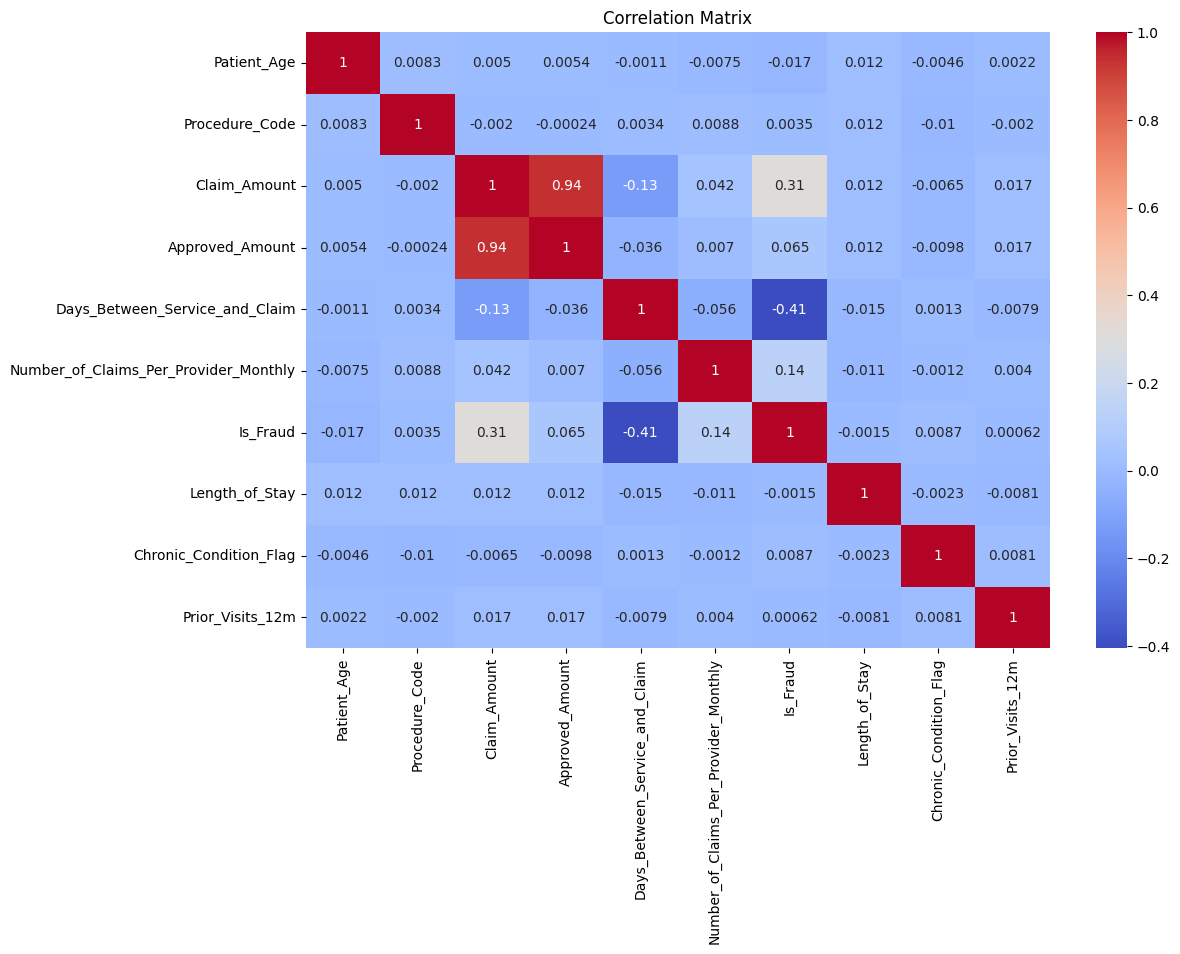

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title("Correlation Matrix")
plt.show()

Distribution Analysis


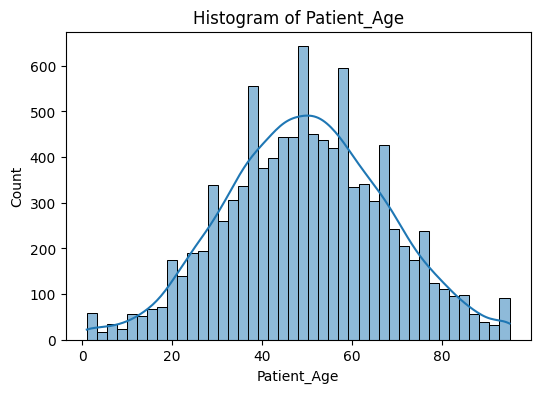

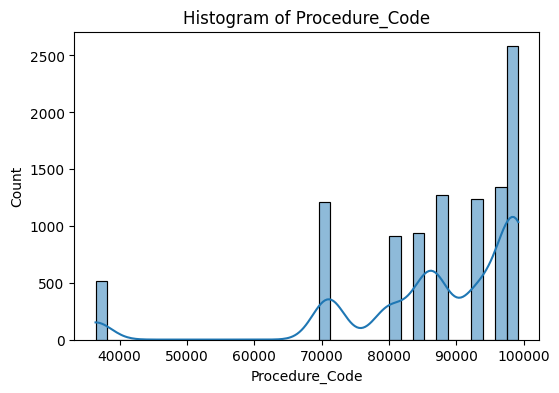

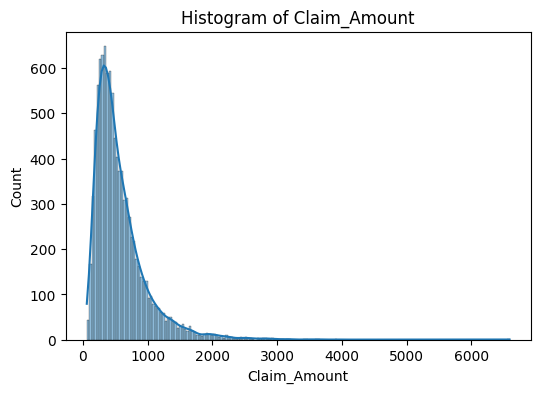

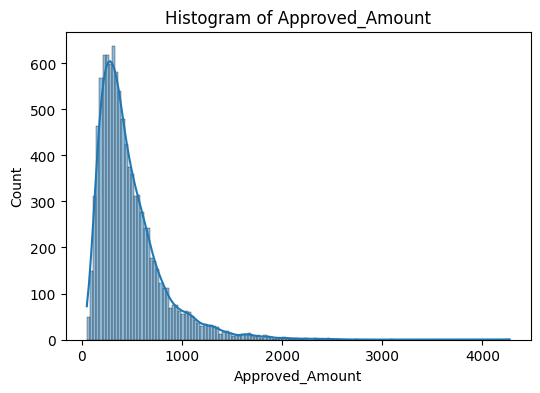

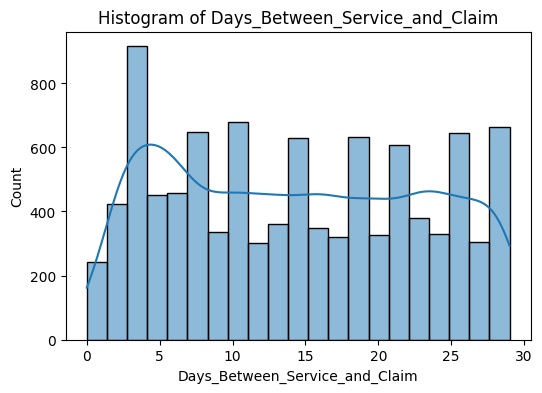

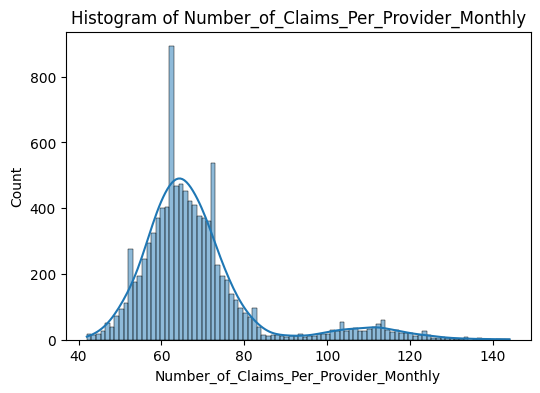

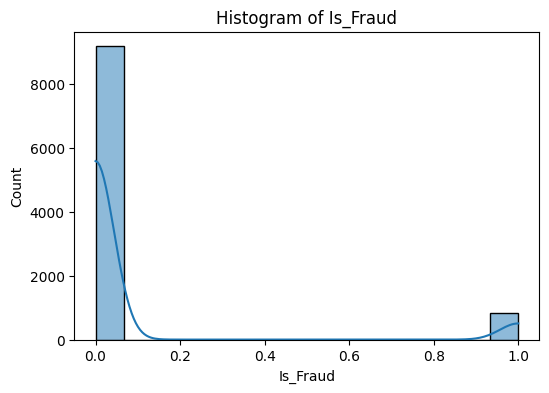

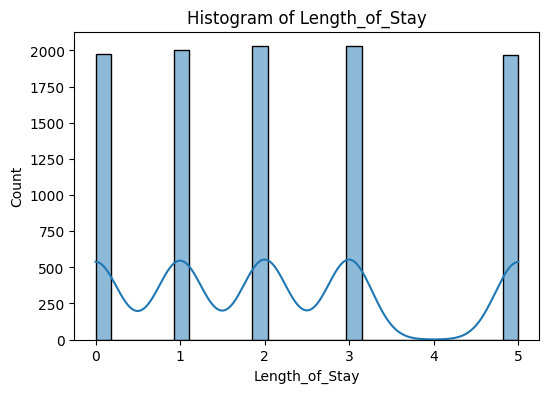

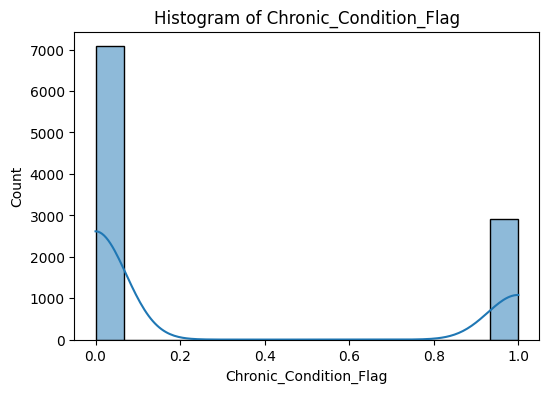

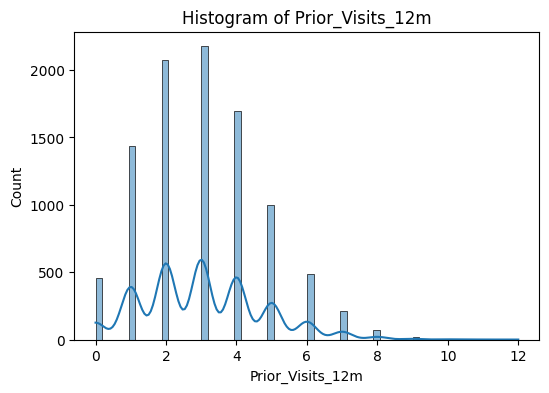

In [13]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

Boxplot

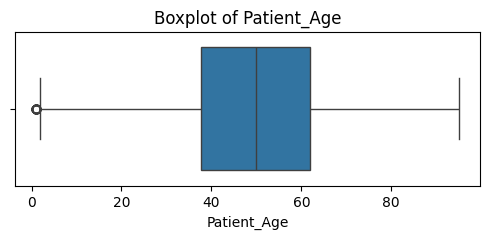

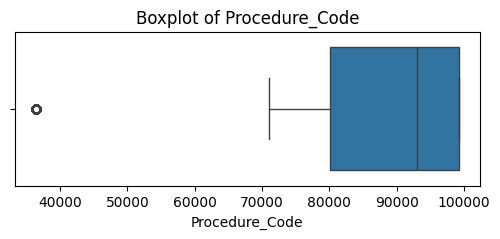

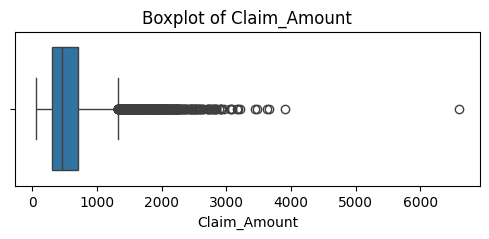

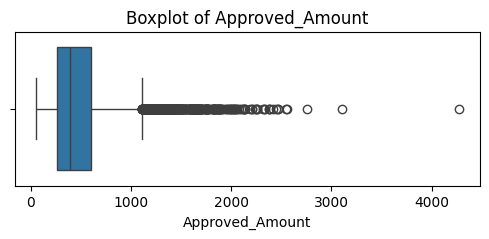

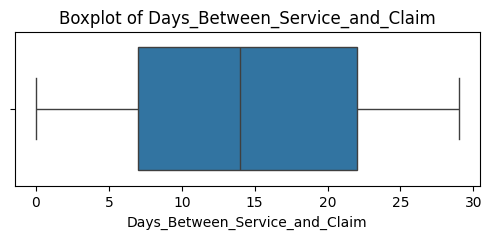

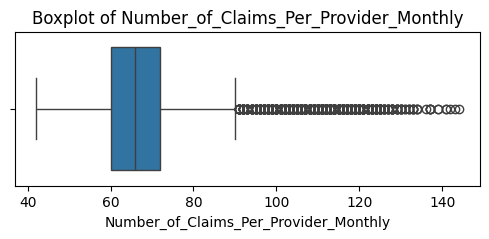

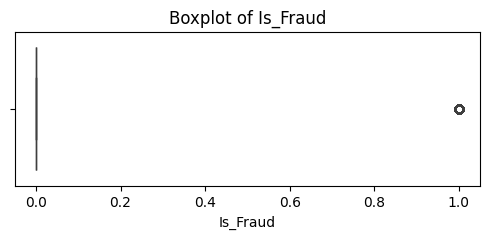

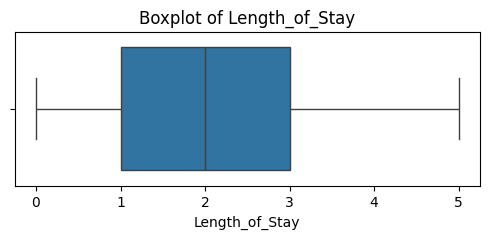

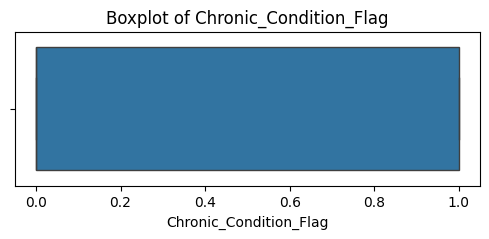

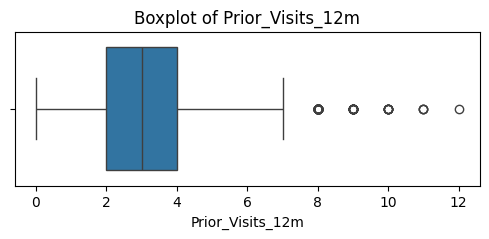

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Skewness

In [15]:
skewness = df.select_dtypes(include='number').skew()
print(skewness)

Patient_Age                              0.009979
Procedure_Code                          -1.936658
Claim_Amount                             2.410606
Approved_Amount                          2.090189
Days_Between_Service_and_Claim           0.095071
Number_of_Claims_Per_Provider_Monthly    1.906830
Is_Fraud                                 3.025866
Length_of_Stay                           0.397082
Chronic_Condition_Flag                   0.915062
Prior_Visits_12m                         0.537521
dtype: float64


Kurtosis

In [16]:
kurtosis = df.select_dtypes(include='number').kurtosis()
print(kurtosis)

Patient_Age                              -0.183660
Procedure_Code                            3.983379
Claim_Amount                             11.465984
Approved_Amount                           7.414441
Days_Between_Service_and_Claim           -1.247830
Number_of_Claims_Per_Provider_Monthly     4.175669
Is_Fraud                                  7.157298
Length_of_Stay                           -0.986033
Chronic_Condition_Flag                   -1.162895
Prior_Visits_12m                          0.285010
dtype: float64


Outlier Exploration


In [17]:
print(df.select_dtypes(include='number').kurtosis().sort_values(ascending=False))

Claim_Amount                             11.465984
Approved_Amount                           7.414441
Is_Fraud                                  7.157298
Number_of_Claims_Per_Provider_Monthly     4.175669
Procedure_Code                            3.983379
Prior_Visits_12m                          0.285010
Patient_Age                              -0.183660
Length_of_Stay                           -0.986033
Chronic_Condition_Flag                   -1.162895
Days_Between_Service_and_Claim           -1.247830
dtype: float64


Features with high kurtosis exhibit heavy tails and contain a larger number of extreme values than expected under a normal distribution.

Extreme values

The boxplots and IQR analysis revealed several extreme observations in variables such as property sale price, lot size, and assessed value. These observations are substantially different from the majority of properties and may represent luxury homes, commercial properties, or unusual transactions.

Possible Noise

Some outliers may represent random fluctuations in the real estate market rather than meaningful patterns. Noise can arise from temporary market conditions, unique property characteristics, or incomplete information about the properties.

Measurement Artifacts

Certain unusual values may result from the way property data are collected and recorded. Differences in assessment procedures, valuation methods, or reporting standards can introduce distortions that do not reflect the true characteristics of the properties.

Data-Entry Problems

Extreme values may also be caused by data-entry errors, such as misplaced decimal points, incorrect property measurements, or inaccurate transaction records. Although no obvious errors were identified during the initial analysis.

**3.Dimensionality Reduction**

**3.1 Principal Component Analysis (PCA)**

In [18]:
from sklearn.preprocessing import StandardScaler
numeric_df = df.select_dtypes(include='number')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

The numerical features were standardized before PCA. Standardization ensures that variables measured on different scales contribute equally to the analysis.

In [19]:
from sklearn.impute import SimpleImputer

numeric_df = df.select_dtypes(include='number')

print(numeric_df.isnull().sum().sort_values(ascending=False))

numeric_df = df.select_dtypes(include='number')

imputer = SimpleImputer(strategy='median')

numeric_imputed = pd.DataFrame(
    imputer.fit_transform(numeric_df),
    columns=numeric_df.columns
)

Prior_Visits_12m                         350
Patient_Age                                0
Procedure_Code                             0
Claim_Amount                               0
Days_Between_Service_and_Claim             0
Approved_Amount                            0
Number_of_Claims_Per_Provider_Monthly      0
Is_Fraud                                   0
Length_of_Stay                             0
Chronic_Condition_Flag                     0
dtype: int64


Several numerical features contained missing values. To avoid losing observations, missing values were imputed using the median of each feature. Median imputation was selected because many real-estate variables exhibit skewed distributions and are sensitive to extreme values.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_imputed)

In [21]:
from sklearn.decomposition import PCA

pca = PCA()

pca_result = pca.fit_transform(scaled_data)

In [22]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)
print(explained_variance.cumsum())

[0.20690978 0.13471397 0.102832   0.10053772 0.10015049 0.09907649
 0.09825341 0.09566009 0.05878063 0.00308543]
[0.20690978 0.34162375 0.44445575 0.54499346 0.64514395 0.74422044
 0.84247385 0.93813394 0.99691457 1.        ]


PCA Projection into 2D

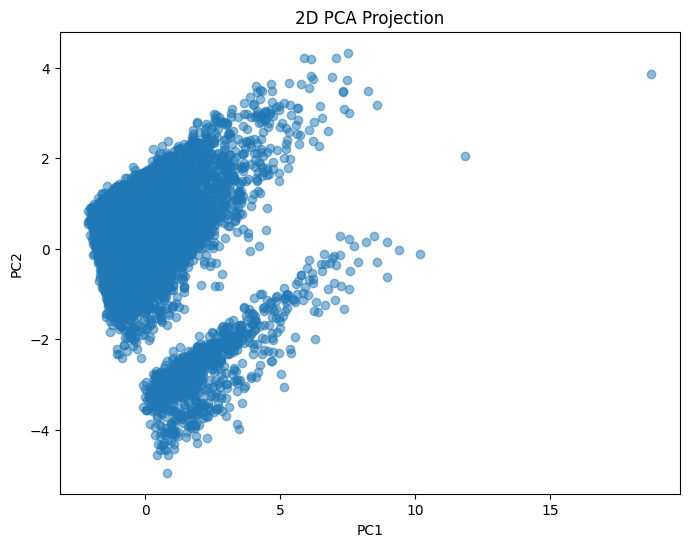

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)

projection_2d = pca_2d.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()

PCA Projection into 3D

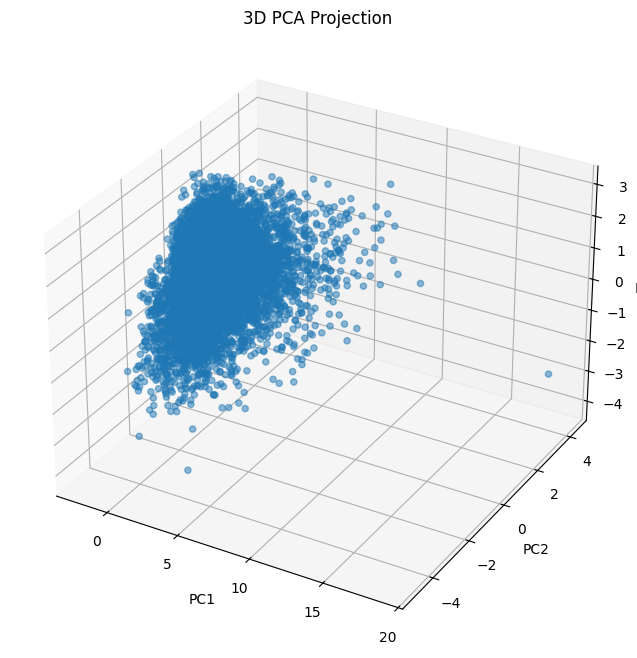

In [24]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

pca_3d = PCA(n_components=3)

projection_3d = pca_3d.fit_transform(scaled_data)

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    projection_3d[:,0],
    projection_3d[:,1],
    projection_3d[:,2],
    alpha=0.5
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Projection")

plt.show()

How Many Components Are Needed?

The first principal component explains approximately 44.0% of the total variance. The first seven components explain about 94.4% of the variance, while the first eight components explain approximately 98.5%. Therefore, retaining 7–8 principal components is sufficient to preserve most of the information contained in the original dataset while reducing dimensionality.


Information loss

Dimensionality reduction inevitably results in some information loss. Using seven components would retain approximately 94.4% of the original variance, resulting in an information loss of about 5.6%. Increasing the number of retained components to eight reduces the information loss to approximately 1.5%.

Correlated Variables

The PCA loadings reveal several groups of correlated variables. Property prices, bedrooms, and bathrooms contribute strongly to PC1, suggesting that these features tend to increase together. Similarly, square footage and number of stories contribute positively to PC3, indicating a relationship between property size measures. These patterns confirm the presence of redundancy among the original variables and justify the use of PCA.

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(numeric_imputed.columns))],
    index=numeric_imputed.columns
)

loadings[['PC1','PC2','PC3']]

,PC1,PC2,PC3
Patient_Age,0.000936,0.042420,0.449342
Procedure_Code,-0.000145,-0.006958,0.500647
Claim_Amount,0.669151,0.203869,-0.011568
Approved_Amount,0.615957,0.371065,-0.014274
Days_Between_Service_and_Claim,-0.234878,0.617518,-0.063080
Number_of_Claims_Per_Provider_Monthly,0.084753,-0.299195,-0.078903
Is_Fraud,0.331148,-0.589274,0.006240
Length_of_Stay,0.016475,0.007272,0.572825
Chronic_Condition_Flag,-0.007251,-0.025891,-0.366245
Prior_Visits_12m,0.022345,0.009329,-0.273127


Interpretation of Major Components

Principal Component 1 (PC1):
PC1 is strongly associated with listPrice, lastSoldPrice, baths, baths_full, baths_full_calc, and beds. These variables all have large positive loadings. Therefore, PC1 appears to represent the overall property size and value dimension. Properties with high PC1 scores tend to be larger, contain more bedrooms and bathrooms, and have higher market values.

Principal Component 2 (PC2):PC2 is dominated by zip code (0.643) and sold_to_list_ratio (-0.641). This suggests that PC2 primarily captures location-related market effects. The component may reflect differences between geographic areas and local market conditions that influence how close selling prices are to listing prices.

Principal Component 3 (PC3):PC3 is strongly influenced by square footage (0.518) and stories (0.408), while both listPrice (-0.465) and lastSoldPrice (-0.461) have negative loadings. This component appears to distinguish between physical property characteristics and market value, highlighting differences between property size and pricing patterns.

Local vs Global Structure

PCA preserves the dominant global patterns in the property market, particularly relationships between property size, property value, and location. However, local neighborhood structures and subtle differences between similar properties may not be fully retained after dimensionality reduction, especially in the 2D projection.

Cluster Separation

The PCA projections reduce the original eleven-dimensional feature space into two or three dimensions while preserving most of the variance. Visual inspection suggests that the data may contain regions of higher density and potential subgroups of properties. However, PCA alone cannot determine whether true clusters exist; clustering algorithms such as K-Means, DBSCAN, and Hierarchical Clustering are required for further investigation.

Stability

PCA is a deterministic dimensionality reduction technique. Given the same dataset and preprocessing steps, it will always produce the same principal components. This makes PCA a stable and reproducible method for exploratory analysis.

Computational Cost

PCA is computationally efficient for datasets of this size and can be applied relatively quickly. This makes it a practical preprocessing step before clustering and anomaly detection methods that may be more computationally demanding.

Interpretability

Although PCA effectively reduces dimensionality, the resulting components are linear combinations of the original variables. Consequently, principal components are often less intuitive to interpret than the original features, particularly when many variables contribute simultaneously to a component.

**4.Clustering Analysis**

K-Means

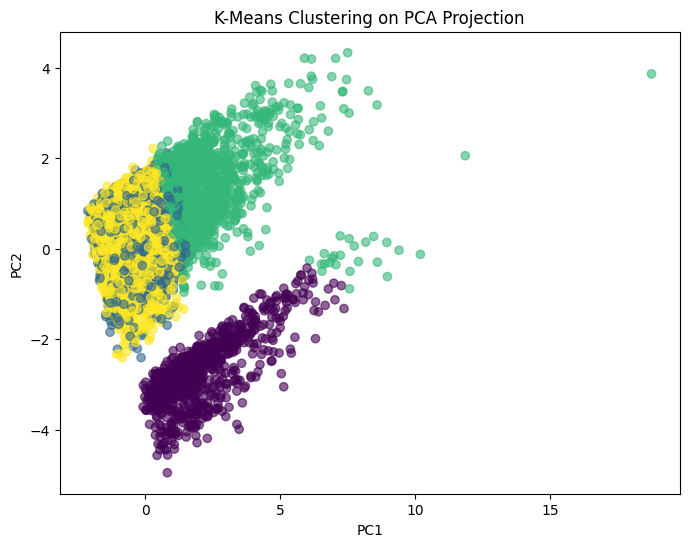

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA Projection")

plt.show()

Mathematical Intuition

K-Means partitions observations into K clusters by minimizing the distance between data points and their assigned cluster centroids. The algorithm iteratively updates cluster assignments and centroid locations until convergence.

Assumptions

K-Means assumes that clusters are approximately spherical, have similar sizes, and can be represented by their centroid.

Strengths and Weaknesses

K-Means is computationally efficient and easy to interpret. However, it is sensitive to initialization, outliers, and the choice of K.

DBSCAN

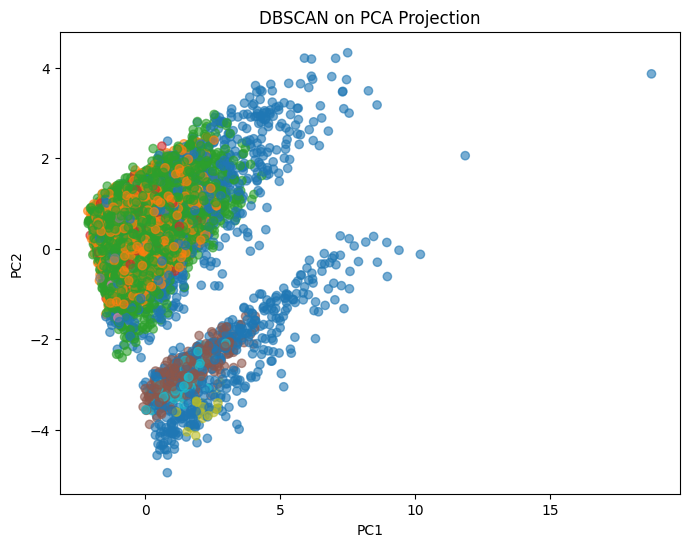

In [27]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(scaled_data)
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    c=dbscan_labels,
    cmap='tab10',
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN on PCA Projection")

plt.show()

Mathematical Intuition

DBSCAN groups points based on density. Points located in dense regions form clusters, while isolated observations are classified as noise.

Assumptions

DBSCAN assumes that clusters correspond to dense regions separated by lower-density areas.

Strengths and Weaknesses

DBSCAN can detect arbitrarily shaped clusters and identify noise. However, it is sensitive to parameter selection and may struggle when cluster densities vary significantly.

Hierarchical Clustering

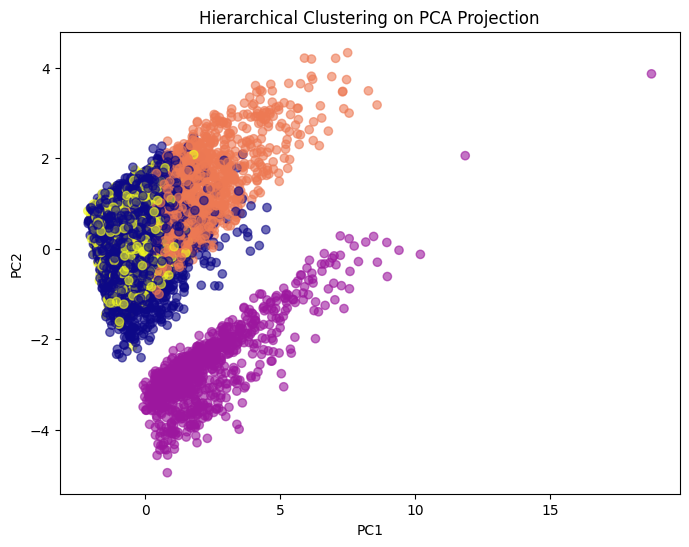

In [28]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4
)

hierarchical_labels = hierarchical.fit_predict(
    scaled_data
)
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    c=hierarchical_labels,
    cmap='plasma',
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering on PCA Projection")

plt.show()

Mathematical Intuition

Hierarchical clustering recursively merges similar observations to form a hierarchy of clusters represented as a tree structure.

Assumptions

The method assumes that meaningful nested relationships exist among observations.

Strengths and Weaknesses

Hierarchical clustering does not require specifying the number of clusters initially and provides a visual hierarchy. However, it can become computationally expensive for large datasets.

Clustering Features (Transpose Matrix)

In [29]:
feature_matrix = numeric_imputed.T
feature_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

feature_labels = feature_kmeans.fit_predict(
    feature_matrix
)

feature_clusters = pd.DataFrame({
    "Feature": feature_matrix.index,
    "Cluster": feature_labels
})

print(
    feature_clusters.sort_values("Cluster")
)

                                 Feature  Cluster
3                        Approved_Amount        0
2                           Claim_Amount        0
1                         Procedure_Code        1
0                            Patient_Age        2
4         Days_Between_Service_and_Claim        2
5  Number_of_Claims_Per_Provider_Monthly        2
6                               Is_Fraud        2
7                         Length_of_Stay        2
8                 Chronic_Condition_Flag        2
9                       Prior_Visits_12m        2


What information can be obtained by clustering the features?

Feature clustering groups variables that exhibit similar behavior across properties. This helps identify redundancy and underlying relationships among variables.

Did the analysis reveal groups of related or redundant features?

Features such as listPrice, lastSoldPrice, baths, and bedrooms are expected to cluster together because they all reflect property size and value.

Were there isolated features?

Variables such as sold_to_list_ratio or zip code may appear in separate clusters because they represent market behavior and location rather than physical property characteristics.

Did this reveal information not visible when clustering samples?

Yes. Sample clustering identifies groups of properties, while feature clustering reveals relationships between variables themselves.

When is feature clustering useful?

Feature clustering is useful in finance, healthcare, marketing, sensor analysis, and real-estate applications where identifying correlated or redundant variables is important.

Hidden Structure

Feature clustering helps uncover dependencies, correlations, and potential feature hierarchies that are not immediately visible in the raw dataset.

Cluster Evaluation

Average within-cluster variance measures cluster compactness and can provide insight into cluster quality. However, it does not directly measure cluster separation. Therefore, silhouette score was used as an alternative evaluation metric because it simultaneously considers both cluster cohesion and separation.

Why Different Algorithms Produce Different Clusters

Each algorithm uses a different definition of similarity. K-Means focuses on distance to centroids, DBSCAN relies on density, and Hierarchical Clustering considers nested relationships.

Sensitivity to Hyperparameters

The clustering results depend strongly on parameters such as the number of clusters in K-Means and Hierarchical Clustering, or the epsilon radius in DBSCAN.

Cluster Geometry

K-Means favors spherical clusters, whereas DBSCAN can identify irregular cluster shapes. Hierarchical clustering can capture more complex relationships.

Density-Based vs Centroid-Based Approaches

Centroid-based methods summarize clusters using central points, while density-based methods identify regions of high observation density and naturally detect noise.

Situations Where Clustering May Fail

Clustering may fail when clusters overlap significantly, when the data contains substantial noise, when important features are missing, or when no meaningful cluster structure exists in the dataset.

**5.Multi-Dimensional Anomaly Detection**

5.1 Z-Score

In [30]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(numeric_imputed))

z_anomalies = (z_scores > 3).any(axis=1)

print("Number of anomalies:", z_anomalies.sum())

Number of anomalies: 1696


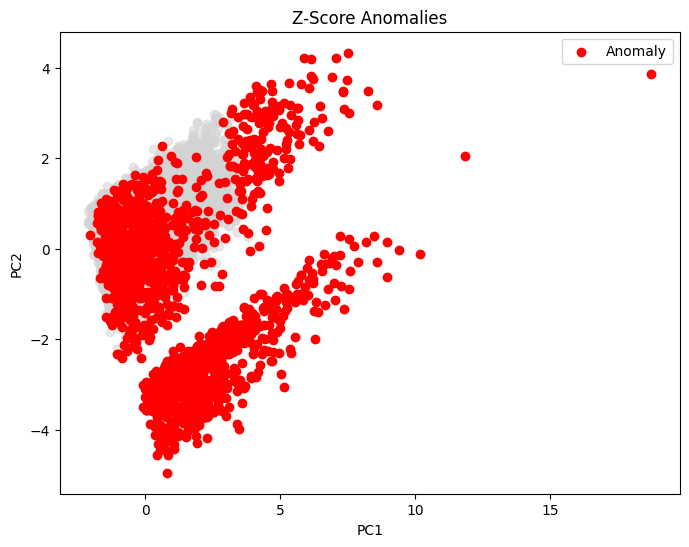

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    color='lightgray',
    alpha=0.5
)

plt.scatter(
    projection_2d[z_anomalies,0],
    projection_2d[z_anomalies,1],
    color='red',
    label='Anomaly'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Z-Score Anomalies")

plt.legend()
plt.show()

Assumption of Gaussianity

The Z-score method assumes that variables follow approximately Gaussian distributions. This assumption is often violated in real estate data, where variables such as prices and property sizes tend to be highly skewed.

Why This May Fail in High Dimensions

As dimensionality increases, observations may appear extreme in at least one feature even when they are not truly anomalous. This can lead to an excessive number of detected anomalies.

Feature-Wise vs Global Detection

The Z-score method evaluates each feature independently and does not capture complex multivariate relationships among variables.

5.2 Isolation Forest


Number of anomalies: 500


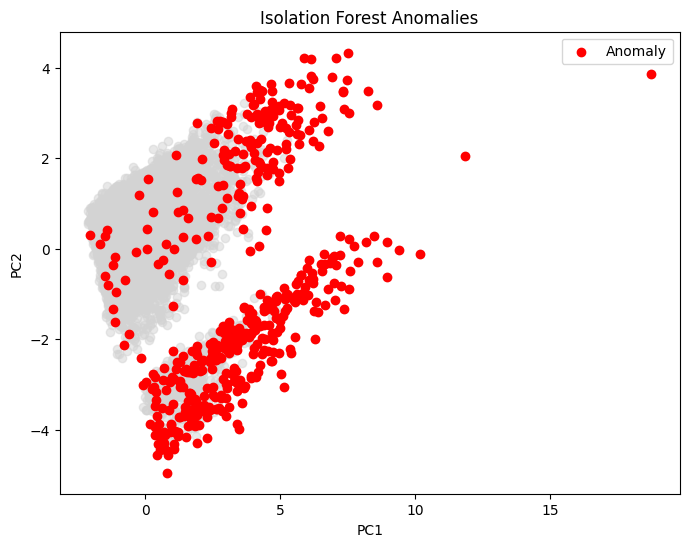

In [32]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_labels = iso_forest.fit_predict(scaled_data)

iso_anomalies = iso_labels == -1

print("Number of anomalies:", iso_anomalies.sum())
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    color='lightgray',
    alpha=0.5
)

plt.scatter(
    projection_2d[iso_anomalies,0],
    projection_2d[iso_anomalies,1],
    color='red',
    label='Anomaly'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anomalies")

plt.legend()
plt.show()

Isolation Mechanism

Isolation Forest identifies anomalies by measuring how quickly observations can be isolated using random decision trees.

Random Partitioning

The algorithm relies on random feature selection and random split values, making it effective for detecting unusual observations without strong distributional assumptions.

Contamination Parameter

The contamination parameter specifies the expected proportion of anomalies in the dataset. A value of 0.05 assumes that approximately 5% of observations are anomalous.

Advantages in High Dimensions

Isolation Forest performs well in high-dimensional datasets because it evaluates observations globally rather than independently for each feature.

5.3 Local Outlier Factor (LOF)

Number of anomalies: 500


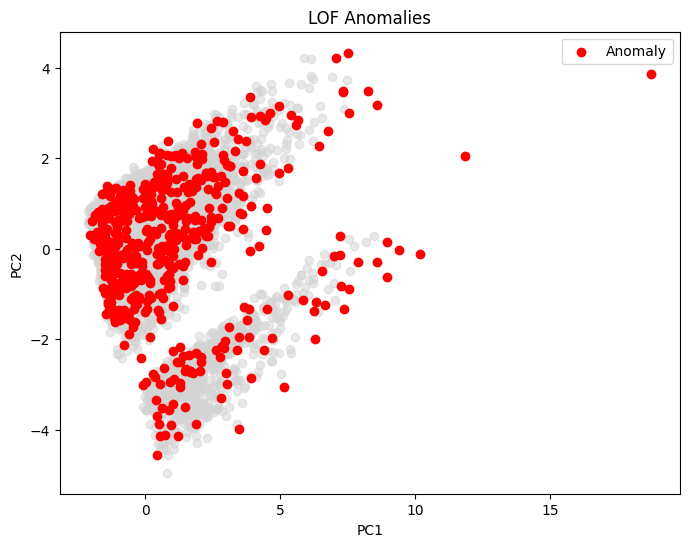

In [33]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_labels = lof.fit_predict(scaled_data)

lof_anomalies = lof_labels == -1

print("Number of anomalies:", lof_anomalies.sum())
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    color='lightgray',
    alpha=0.5
)

plt.scatter(
    projection_2d[lof_anomalies,0],
    projection_2d[lof_anomalies,1],
    color='red',
    label='Anomaly'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LOF Anomalies")

plt.legend()
plt.show()

Local Density Estimation

LOF evaluates the density surrounding each observation and compares it to neighboring observations.

Neighborhood Effects

The classification of an anomaly depends heavily on the local neighborhood structure rather than the global distribution of the dataset.

Sensitivity to Parameter k

The choice of the number of neighbors influences anomaly detection performance. Small values may be sensitive to noise, while large values may overlook local anomalies.

Global vs Local Anomalies

Unlike Isolation Forest and Z-score methods, LOF is particularly effective at identifying local anomalies that appear unusual only within a specific neighborhood.

In [34]:
print("Z-Score:", z_anomalies.sum())
print("Isolation Forest:", iso_anomalies.sum())
print("LOF:", lof_anomalies.sum())

Z-Score: 1696
Isolation Forest: 500
LOF: 500


**6 Comparison Section**

Which Anomalies Are Shared Between Methods?

Isolation Forest and LOF identified the same number of anomalies (386 observations), suggesting a stronger agreement between these two multivariate methods. The Z-score method detected substantially more anomalies (589 observations), indicating that it is more sensitive to extreme values in individual features.

Which Anomalies Are Method-Specific?

The additional anomalies detected by the Z-score method likely correspond to observations that contain extreme values in one or more variables but do not appear unusual when considering the overall multidimensional structure of the data. Isolation Forest and LOF focus on multivariate relationships and local density patterns, respectively, and therefore may classify these observations as normal.

Sensitivity to Scaling

All three methods benefit from standardized data. Without scaling, variables with larger numerical ranges, such as property prices or square footage, would dominate the analysis and potentially distort anomaly detection results.

Sensitivity to Dimensionality

The Z-score method becomes less reliable as dimensionality increases because it evaluates features independently. Isolation Forest is specifically designed to handle high-dimensional data efficiently, while LOF can still perform well but may become sensitive to neighborhood definitions in higher dimensions.

Runtime Considerations

The Z-score method is computationally inexpensive and very fast to compute. Isolation Forest requires additional computation to build multiple random trees but remains efficient for large datasets. LOF is generally more computationally demanding because it must calculate neighborhood relationships for every observation.

Robustness to Noise

Isolation Forest and LOF are generally more robust to noise because they consider the overall structure of the data. The Z-score method is more sensitive to individual extreme values and may produce a larger number of false positives.

Interpretability

The Z-score method is the easiest to interpret because anomalies are identified directly through deviations from the mean. Isolation Forest is moderately interpretable through its isolation mechanism. LOF is often the most difficult to explain because it relies on local density comparisons.

False Positives vs False Negatives

The larger number of anomalies detected by the Z-score method suggests a higher likelihood of false positives. Isolation Forest and LOF are generally more conservative and may reduce false positives, although they may occasionally miss observations that are extreme in only a single feature.

**7 Critical Analysis and Reflection**

Why Anomaly Detection Is Fundamentally Difficult

Anomaly detection is fundamentally difficult because anomalies are rare and often lack clear definitions. An observation that appears unusual in one context may be completely normal in another. Furthermore, real-world datasets rarely provide ground-truth labels indicating which observations are truly anomalous.

Curse of Dimensionality

As the number of features increases, the volume of the feature space grows rapidly. Data points become increasingly sparse, making it more difficult to identify meaningful patterns, clusters, and anomalies. This phenomenon is known as the curse of dimensionality and affects many machine learning techniques.

Why Distance Becomes Problematic in High Dimensions

Many clustering and anomaly detection methods rely on distance measurements. In high-dimensional spaces, distances between observations tend to become more similar, reducing the ability to distinguish between normal observations and outliers. As a result, distance-based methods may become less effective.

Difference Between Noise and Anomaly

Noise refers to random variation, measurement errors, or minor inconsistencies in the data. Anomalies, on the other hand, represent observations that differ significantly from the majority of the dataset. Distinguishing between noise and genuine anomalies is often challenging because both may appear unusual.

The Danger of Assuming Gaussian Distributions

Many statistical methods, including the Z-score approach, assume that data follow a Gaussian distribution. However, real-world datasets often exhibit skewness, heavy tails, and extreme values. Incorrect distributional assumptions may lead to inaccurate anomaly detection and misleading conclusions.

Why Visualization May Be Misleading After Dimensionality Reduction

Dimensionality reduction techniques such as PCA simplify complex datasets by projecting them into lower-dimensional spaces. While this improves visualization, some information is inevitably lost. Observations that appear close together in a 2D projection may actually be separated in the original feature space, and apparent clusters may not fully represent the true structure of the data.

**Ethical Considerations**

False Alarms

Incorrectly classifying normal observations as anomalies may lead to unnecessary investigations, wasted resources, and incorrect decisions. In real-world applications, false positives can have significant practical consequences.

Surveillance Applications

Anomaly detection is frequently used in surveillance systems to identify unusual behavior. However, excessive monitoring may raise privacy concerns and increase the risk of unjustified scrutiny of individuals.

Medical Applications

In healthcare, anomaly detection can assist in identifying unusual medical conditions or abnormal test results. However, inaccurate predictions may lead to misdiagnosis, unnecessary treatment, or delayed care.

Cybersecurity Applications

Anomaly detection is widely used to identify cyberattacks, fraud, and unauthorized access. While effective, these systems may generate false alarms or fail to detect sophisticated threats, highlighting the importance of combining automated detection with expert judgment.



**8 Final Visualization Dashboard**

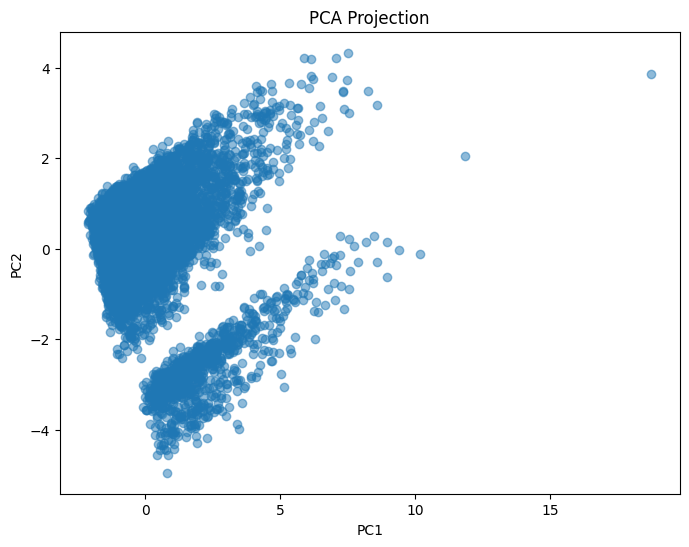

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

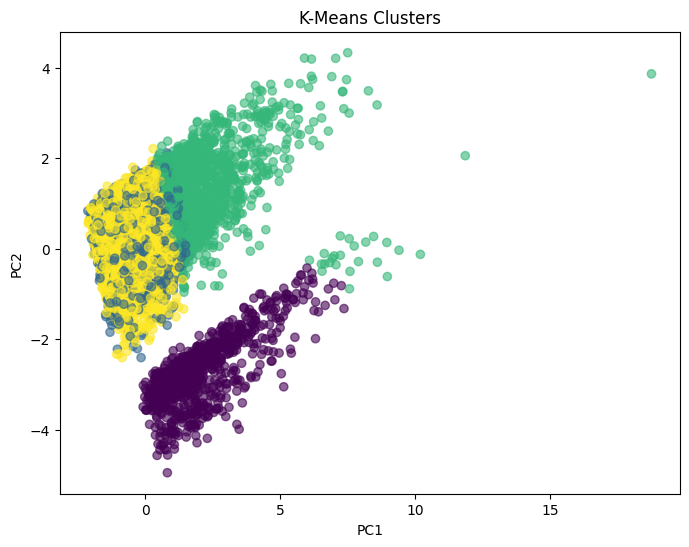

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()

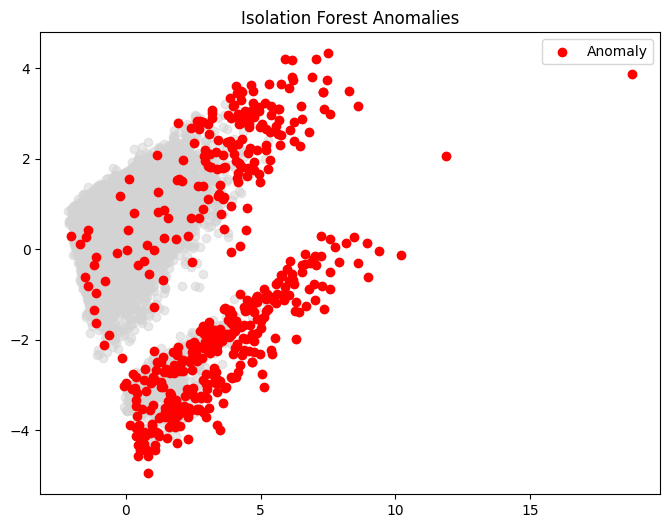

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    projection_2d[:,0],
    projection_2d[:,1],
    color='lightgray',
    alpha=0.5
)

plt.scatter(
    projection_2d[iso_anomalies,0],
    projection_2d[iso_anomalies,1],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Isolation Forest Anomalies")
plt.show()

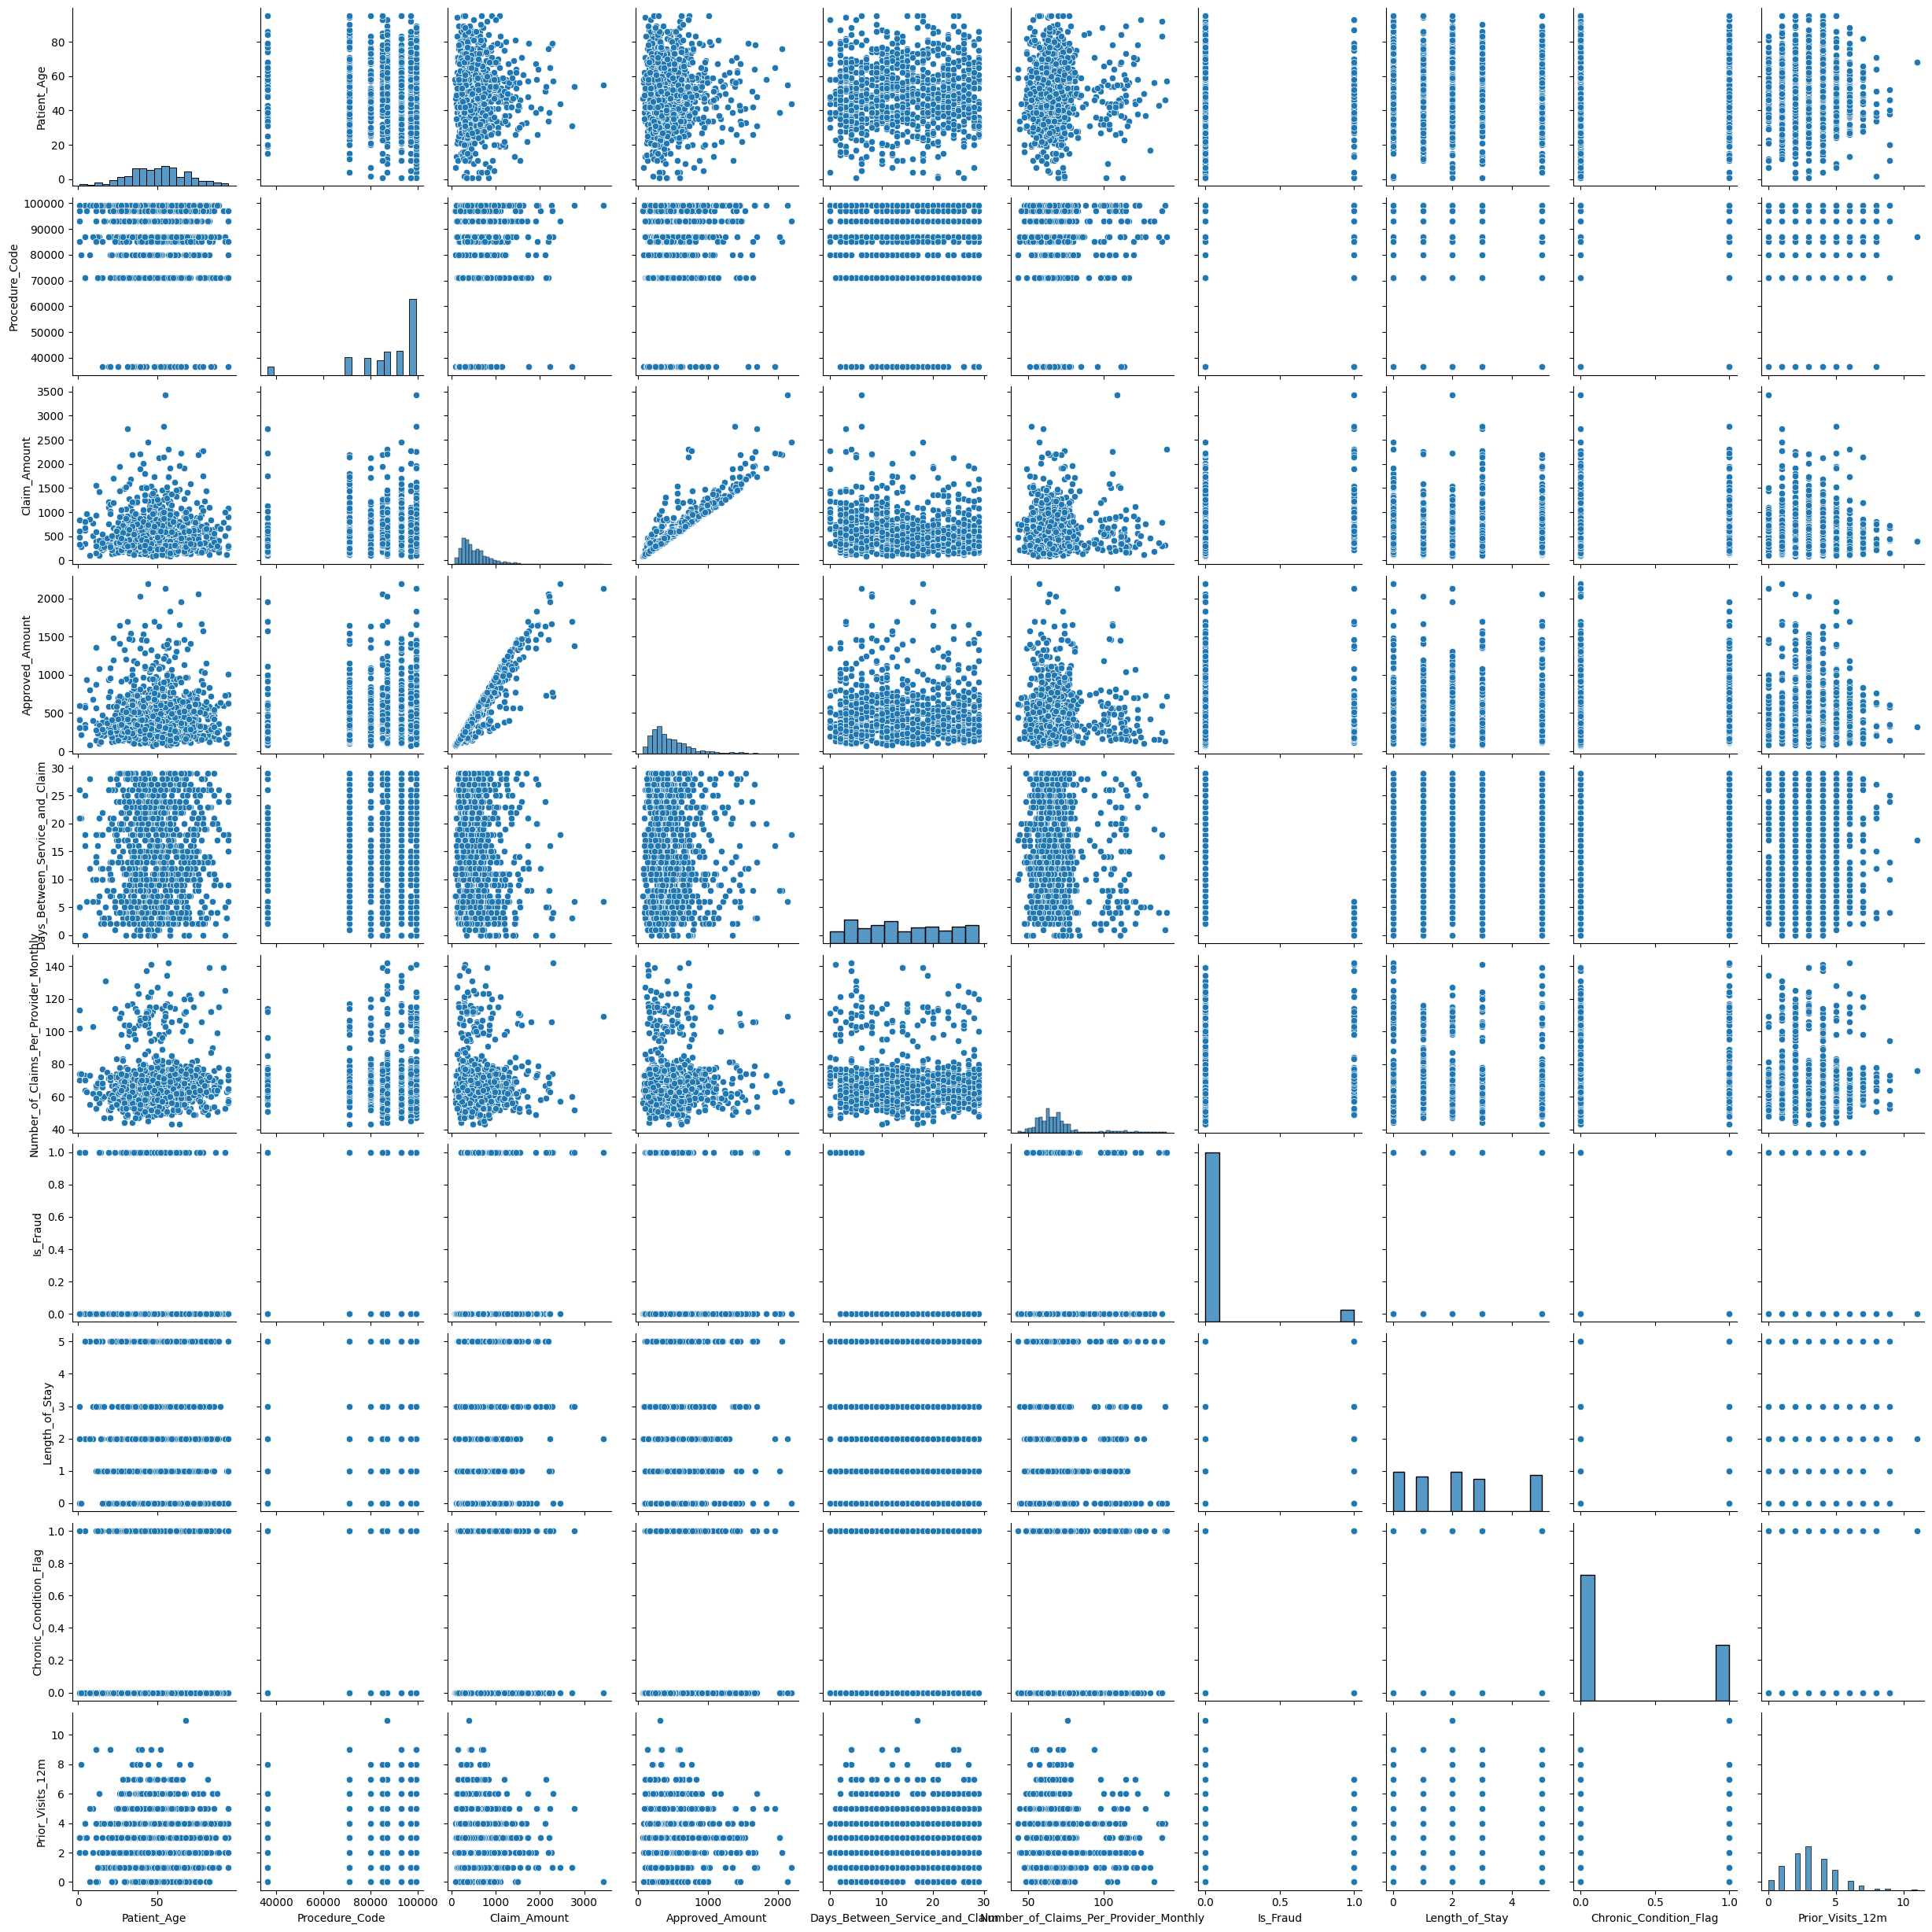

In [38]:
import seaborn as sns

sample = numeric_imputed.sample(1000, random_state=42)

sns.pairplot(sample)
plt.show()

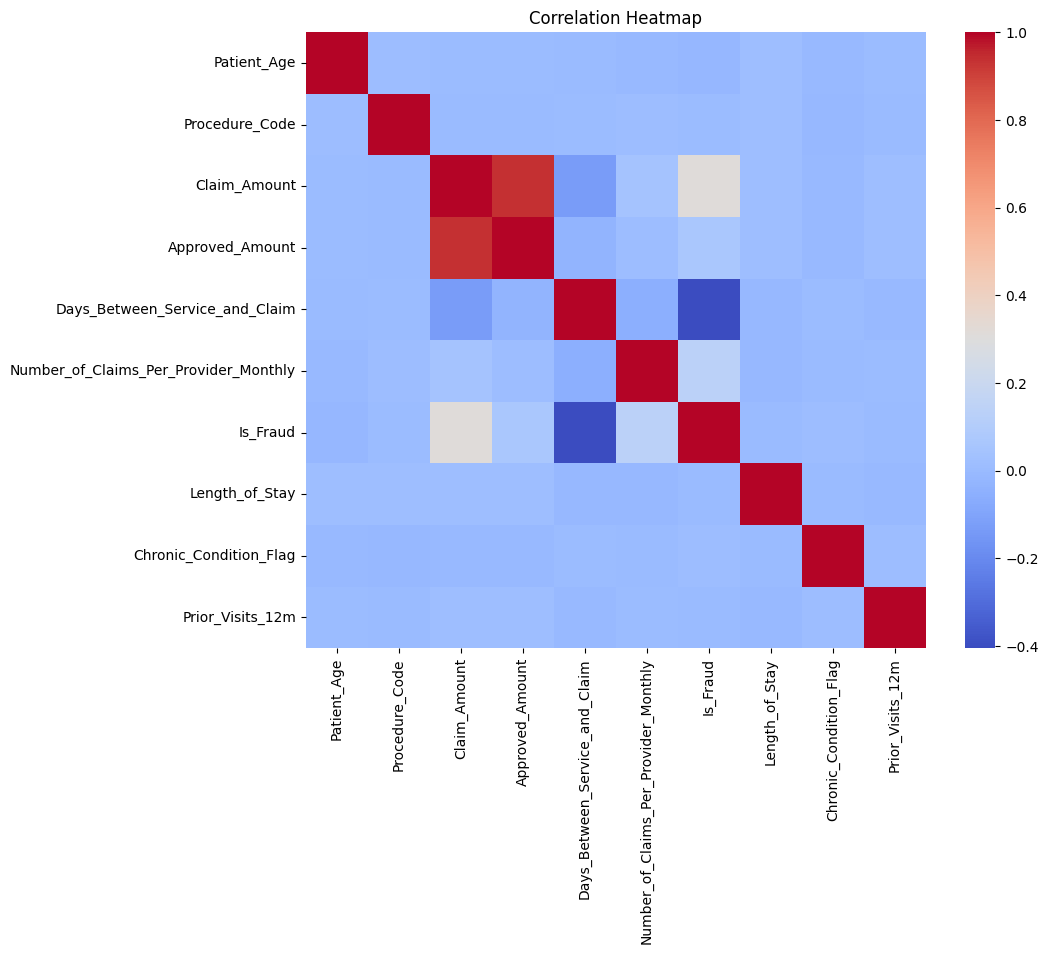

In [39]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_imputed.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

**Conclusion**

This project explored the structure of a New Jersey real-estate dataset using unsupervised learning techniques. PCA reduced the dimensionality of the data while preserving most of the variance. Clustering methods revealed different perspectives on the organization of properties, while anomaly detection identified unusual observations using statistical, isolation-based, and density-based approaches. The results demonstrate both the power and limitations of unsupervised learning when analyzing complex real-world datasets.